In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import os
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split

# 1. Hardware Verification
print(f"✅ GPU Active: {torch.cuda.is_available()}")

# 2. Force Remount (Clears the 'Input/output error')
try:
    drive.flush_and_unmount()
except:
    pass
drive.mount('/content/drive', force_remount=True)

# 3. Path Setup
AUDIO_DIR = "/content/drive/MyDrive/manual_datasets/clovacall_data/wavs_resampled_16k/"
TRAIN_JSON = "/content/drive/MyDrive/manual_datasets/clovacall_data/train_ClovaCall.json"
TEST_JSON = "/content/drive/MyDrive/manual_datasets/clovacall_data/test_ClovaCall.json"

# 4. Metadata Loading
train_df_full = pd.read_json(TRAIN_JSON)
test_df_full = pd.read_json(TEST_JSON)
metadata = pd.concat([train_df_full, test_df_full], ignore_index=True)

# 5. BYPASS THE LS ERROR
# Instead of listing 60k files, we will just assume they exist and
# handle missing ones later in our "Safe Dataset" loader.
print("⚠️ Skipping 'ls' to avoid I/O crash. Proceeding with full metadata...")
metadata_filtered = metadata.copy()

# 6. Final Splits
train_df, temp_df = train_test_split(metadata_filtered, test_size=0.2, random_state=42)
val_df, _ = train_test_split(temp_df, test_size=0.5, random_state=42)

# Selecting subsets for your ASR Jamo training
train_subset = train_df.sample(n=10000, random_state=42)
val_subset = val_df.sample(n=1000, random_state=42)
print(f"✅ Metadata prepared: {len(train_subset)} training samples ready.")

✅ GPU Active: True
Mounted at /content/drive
⚠️ Skipping 'ls' to avoid I/O crash. Proceeding with full metadata...
✅ Metadata prepared: 10000 training samples ready.


In [ ]:
!pip install jamo

In [ ]:
from jamo import h2j, j2hcj
from torch.utils.data import Dataset
import torchaudio
import time

class JamoASRDataset(Dataset):
    def __init__(self, df, processor, target_dir):
        self.df = df
        self.processor = processor
        self.target_dir = target_dir

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        wav_filename = self.df.iloc[idx]['wav']
        wav_path = os.path.join(self.target_dir, wav_filename)

        # Safe Loader with Skip-Logic
        speech = None
        try:
            # We try once. If Drive gives an I/O error, we return a 1-sec silence
            # so the model doesn't crash.
            speech, _ = torchaudio.load(wav_path)
        except Exception:
            # Return silence for missing/locked files to keep training alive
            speech = torch.zeros(1, 16000)

        input_values = self.processor(speech.squeeze().numpy(), sampling_rate=16000).input_values[0]
        jamo_text = j2hcj(h2j(self.df.iloc[idx]['text']))
        labels = self.processor(text=jamo_text).input_ids
        return {"input_values": input_values, "labels": labels}

In [ ]:
import shutil
import os
from tqdm.auto import tqdm

# 1. Define the local folder (Fast SSD)
LOCAL_WAV_DIR = "/content/local_wavs/"
os.makedirs(LOCAL_WAV_DIR, exist_ok=True)

# 2. Targeted Copy (Bypasses the 'ls' indexing crash)
print("🚀 Localization starting: Moving ASR data to local disk...")

# We use the subsets created in Block 1
files_to_copy = list(set(train_subset['wav'].tolist() + val_subset['wav'].tolist()))
total_files = len(files_to_copy)

copied_count = 0
skipped_count = 0

for f in tqdm(files_to_copy, desc="Localizing Audio"):
    src = os.path.join(AUDIO_DIR, f)
    dst = os.path.join(LOCAL_WAV_DIR, f)

    try:
        # Direct copy without pre-scanning the directory
        shutil.copy(src, dst)
        copied_count += 1
    except (OSError, FileNotFoundError):
        # This handles 'ghost' files without crashing the process
        skipped_count += 1

# 3. Finalize Datasets for Local Access
train_dataset = JamoASRDataset(train_subset, processor, LOCAL_WAV_DIR)
val_dataset = JamoASRDataset(val_subset, processor, LOCAL_WAV_DIR)

print(f"✅ Fast-load ready: {copied_count} files moved to local disk.")
print(f"⚠️ {skipped_count} missing files were automatically skipped.")

🚀 Localization starting: Moving ASR data to local disk...


Localizing Audio:   0%|          | 0/11000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from transformers import Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor, Wav2Vec2Processor, Wav2Vec2ForCTC

# 1. Re-load the Jamo Tokenizer
# Ensure this path matches your GP2.ipynb setup
vocab_path = "/content/drive/MyDrive/manual_datasets/clovacall_data/jamo_vocab.json"

tokenizer = Wav2Vec2CTCTokenizer(
    vocab_path,
    unk_token="[UNK]",
    pad_token="[PAD]",
    word_delimiter_token="|"
)

# 2. Re-load Feature Extractor & Processor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("Kkonjeong/wav2vec2-base-korean")
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)

# 3. Re-load the Model (Resize to 99 tokens for Jamo ASR)
model = Wav2Vec2ForCTC.from_pretrained(
    "Kkonjeong/wav2vec2-base-korean",
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
    ignore_mismatched_sizes=True
).to("cuda") # Ensure it's on the Tesla T4 GPU

print(f"✅ Processor and Model are back in memory. Vocab size: {len(processor.tokenizer)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: Kkonjeong/wav2vec2-base-korean
Key            | Status   |                                                                                       
---------------+----------+---------------------------------------------------------------------------------------
lm_head.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([56, 768]) vs model:torch.Size([82, 768])
lm_head.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([56]) vs model:torch.Size([82])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Processor and Model are back in memory. Vocab size: 82


In [ ]:
# These lines point your training subsets to the audio you just localized
train_dataset = JamoASRDataset(train_subset, processor, LOCAL_WAV_DIR)
val_dataset = JamoASRDataset(val_subset, processor, LOCAL_WAV_DIR)

print("🚀 Datasets finalized with local paths. Ready for training!")

🚀 Datasets finalized with local paths. Ready for training!


In [ ]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorCTCWithPadding:
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # 1. Split inputs and labels
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        # 2. Pad the audio inputs
        batch = self.processor.feature_extractor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # 3. Pad the Jamo text labels
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # 4. Replace padding with -100 so CTC loss ignores it
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels

        return batch

# Initialize the collator using the processor we just re-defined
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)
print("✅ Data Collator is defined and ready for the Trainer.")

✅ Data Collator is defined and ready for the Trainer.


In [ ]:
from transformers import TrainingArguments, Trainer, TrainerCallback

# 1. Training Configuration
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo",
    group_by_length=False,        # Critical: Skip the slow pre-scan since audio is local
    save_steps=100,               # Saves a backup to your Drive every 100 steps
    logging_steps=10,             # Shows you the loss every 10 steps
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4, # Effective batch size = 32 (8 x 4) for stability
    num_train_epochs=10,          # Full 10-epoch run for Jamo convergence
    fp16=True,                    # Uses the Tesla T4 GPU's mixed-precision speed
    learning_rate=1e-4,           # Standard fine-tuning rate for Wav2Vec2
    save_total_limit=2,           # Keeps only the 2 most recent checkpoints to save Drive space
    dataloader_num_workers=2,     # Pre-loads audio in the background
    warmup_steps=100,             # Slowly ramps up learning to prevent loss spikes
    report_to="none"
)

# 2. Progress Tracker (Optional but helpful)
# This forces the Loss to print to your screen so you know the model is learning
class VisualProgressCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs:
            print(f"✅ Step {state.global_step}: Loss = {logs['loss']:.4f}")

# 3. Initialize the Trainer
trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=processor,
    callbacks=[VisualProgressCallback()]
)


In [ ]:
# 4. GO!
print("🚀 Training starting... Look for the loss to start around 20-30 and drop toward 0.")
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 81, 'bos_token_id': 80}.


🚀 Training starting... Look for the loss to start around 20-30 and drop toward 0.


Step,Training Loss
10,132.866016
20,110.025476
30,64.810620
40,27.479611
50,18.236755
60,16.559758
70,15.437747
80,14.544788
90,14.108911
100,13.580882


✅ Step 10: Loss = 132.8660
✅ Step 20: Loss = 110.0255
✅ Step 30: Loss = 64.8106
✅ Step 40: Loss = 27.4796
✅ Step 50: Loss = 18.2368
✅ Step 60: Loss = 16.5598
✅ Step 70: Loss = 15.4377
✅ Step 80: Loss = 14.5448
✅ Step 90: Loss = 14.1089
✅ Step 100: Loss = 13.5809


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

✅ Step 3010: Loss = 0.7485
✅ Step 3020: Loss = 0.7834
✅ Step 3030: Loss = 0.7313
✅ Step 3040: Loss = 0.6662
✅ Step 3050: Loss = 0.5467
✅ Step 3060: Loss = 0.6143
✅ Step 3070: Loss = 0.6631
✅ Step 3080: Loss = 0.7734
✅ Step 3090: Loss = 0.6680
✅ Step 3100: Loss = 0.6856


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Step 3110: Loss = 0.6062
✅ Step 3120: Loss = 0.6347
✅ Step 3130: Loss = 0.6958


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3130, training_loss=3.119807940778641, metrics={'train_runtime': 3610.9861, 'train_samples_per_second': 27.693, 'train_steps_per_second': 0.867, 'total_flos': 4.859726670537554e+18, 'train_loss': 3.119807940778641, 'epoch': 10.0})

In [ ]:
# Define the final path for your Korean Tutor App model
final_model_path = "/content/drive/MyDrive/manual_datasets/clovacall_data/final_asr_jamo_model"

# Save the model weights and the processor (very important for inference later)
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)

print(f"✅ Model and Processor safely saved to: {final_model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and Processor safely saved to: /content/drive/MyDrive/manual_datasets/clovacall_data/final_asr_jamo_model


In [ ]:
# This will run the model on your validation set and give you the final loss
metrics = trainer.evaluate()
print("--- Final Evaluation Metrics ---")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

--- Final Evaluation Metrics ---
eval_loss: 0.2893
eval_runtime: 16.3052
eval_samples_per_second: 61.3300
eval_steps_per_second: 7.6660
epoch: 10.0000


In [ ]:
import torch

# 1. Take a sample from the validation set
sample = val_dataset[0]
input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to("cuda")

# 2. Get predictions (Logits)
with torch.no_grad():
    logits = model(input_values).logits

# 3. Decode the Jamo tokens
predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]

# 4. Final Output (Jamo to Hangul)
from jamo import j2h
print(f"✨ Predicted Jamo: {transcription}")
# Note: You might need a small helper to join Jamos back into syllables for the UI

✨ Predicted Jamo: ㅇ2ㄷㅎㅢ ㅂㅓㄴㅎㅗㄴㅡㄴ 01078288282ㅇㅣㅂㄴㅣㄷㅏ.


In [ ]:
!pip install jamotools

In [ ]:
import jamotools

def post_process_prediction(jamo_text):
    # jamotools.join_jamos takes a string of Jamos and recomposes them into Hangul blocks
    # It automatically handles the Lead-Vowel-Tail logic for modern Korean.
    hangul_text = jamotools.join_jamos(jamo_text)
    return hangul_text

# --- Test with your actual ASR prediction ---
raw_pred = "ㅇ2ㄷㅎㅢ ㅂㅓㄴㅎㅗㄴㅡㄴ 01078288282ㅇㅣㅂㄴㅣㄷㅏ."
final_output = post_process_prediction(raw_pred)

print(f"🎤 Raw Model Output: {raw_pred}")
print(f"📱 App UI Display:   {final_output}")

🎤 Raw Model Output: ㅇ2ㄷㅎㅢ ㅂㅓㄴㅎㅗㄴㅡㄴ 01078288282ㅇㅣㅂㄴㅣㄷㅏ.
📱 App UI Display:   ㅇ2ㄷ희 번호는 01078288282입니다.


In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from jiwer import wer, cer
import torch
import jamotools

def generate_performance_table(model, dataset, processor, num_samples=10):
    model.eval()
    results = []

    # We'll take a few samples to showcase in your presentation
    for i in range(num_samples):
        # 1. Get sample
        sample = dataset[i]
        input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to("cuda")

        # 2. Reference (Ground Truth)
        # Recompose the true Jamo back to Hangul
        ref_jamo = processor.decode(sample["labels"], group_tokens=False).replace("[PAD]", "").replace("|", " ").strip()
        reference_text = jamotools.join_jamos(ref_jamo)

        # 3. Prediction
        with torch.no_grad():
            logits = model(input_values).logits
        pred_ids = torch.argmax(logits, dim=-1)
        pred_jamo = processor.batch_decode(pred_ids)[0]
        prediction_text = jamotools.join_jamos(pred_jamo)

        # 4. Calculate Errors
        # We use 'cer' here because Jamo/Character accuracy is often more
        # meaningful for Korean learners than full Word error rates.
        phoneme_error_rate = cer(reference_text, prediction_text)

        results.append({
            "Sample ID": i + 1,
            "Reference (Ground Truth)": reference_text,
            "Prediction (Model Output)": prediction_text,
            "PER (%)": f"{phoneme_error_rate * 100:.2f}%"  # Labeled correctly as PER
        })

    return pd.DataFrame(results)

# Generate and display the table
report_df = generate_performance_table(model, val_dataset, processor)
display(report_df)

,Sample ID,Reference (Ground Truth),Prediction (Model Output),PER (%)
0,1,"이도희, 번호는 010-7878-8282 입니다.",ㅇ2ㄷ희 번호는 01078288282입니다.,29.63%
1,2,중간에 쉬는 타임이 있나요? 몇시부터 몇시에요?,중간에 쉬는 사임이 있나요? 몇 시부터 몇시에요?,7.69%
2,3,몇 시부터 몇 시까지 열어요?,몇시부터 몇시까지 열어요?,12.50%
3,4,안녕하세요. 어린이들과 함께 먹을 메뉴 추천 부탁드립니다.,안녕하세요. 어린이들과 함께 먹을 메뉴 추천 부탁드립니다.,0.00%
4,5,내일 저녁 7시요.,내일 저녁 7시요.,0.00%
5,6,영업시간이 언제까지인가요?,영업시간이 언제까지인가요?,0.00%
6,7,몇 시부터 몇 시까지 영업하나요?,몇시부터 몇시까지 영업하나요?,11.11%
7,8,오늘 한시에 예약 가능할까요?,오늘 1시에 예약 가능할까요?,6.25%
8,9,예약 하려면 어떻게 해야하나요?,예약하려면 어떻게 해야하나요?,5.88%
9,10,혹시 11시에도 하시나요?,혹시 11시에도 하시나요?,0.00%


In [ ]:
# Define your project's results folder
results_dir = "/content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo/"
os.makedirs(results_dir, exist_ok=True)

# 1. Save as CSV (Standard for research data)
# 'utf-8-sig' ensures Excel recognizes the Korean characters correctly
csv_path = os.path.join(results_dir, "asr_jamo_performance_report.csv")
report_df.to_csv(csv_path, index=False, encoding='utf-8-sig')

# 2. Save as Excel (Easier for formatting tables in your paper)
excel_path = os.path.join(results_dir, "asr_jamo_performance_report.xlsx")
report_df.to_excel(excel_path, index=False)

print(f"✅ Performance reports saved to Drive:\n1. {csv_path}\n2. {excel_path}")

✅ Performance reports saved to Drive:
1. /content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo/asr_jamo_performance_report.csv
2. /content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo/asr_jamo_performance_report.xlsx


/tmp/ipykernel_7679/3074689563.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, bbox_inches='tight', dpi=300)
/tmp/ipykernel_7679/3074689563.py:16: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, bbox_inches='tight', dpi=300)
/tmp/ipykernel_7679/3074689563.py:16: UserWarning: Glyph 55148 (\N{HANGUL SYLLABLE HYI}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, bbox_inches='tight', dpi=300)
/tmp/ipykernel_7679/3074689563.py:16: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, bbox_inches='tight', dpi=300)
/tmp/ipykernel_7679/3074689563.py:16: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.savefig(filename, bbox_inches='tight', dpi=300)
/tmp/ipykernel_7679/3074689563.py:16: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu 

📸 Presentation-ready image saved: /content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo/performance_table_slide.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55148 (\N{HANGUL SYLLABLE HYI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

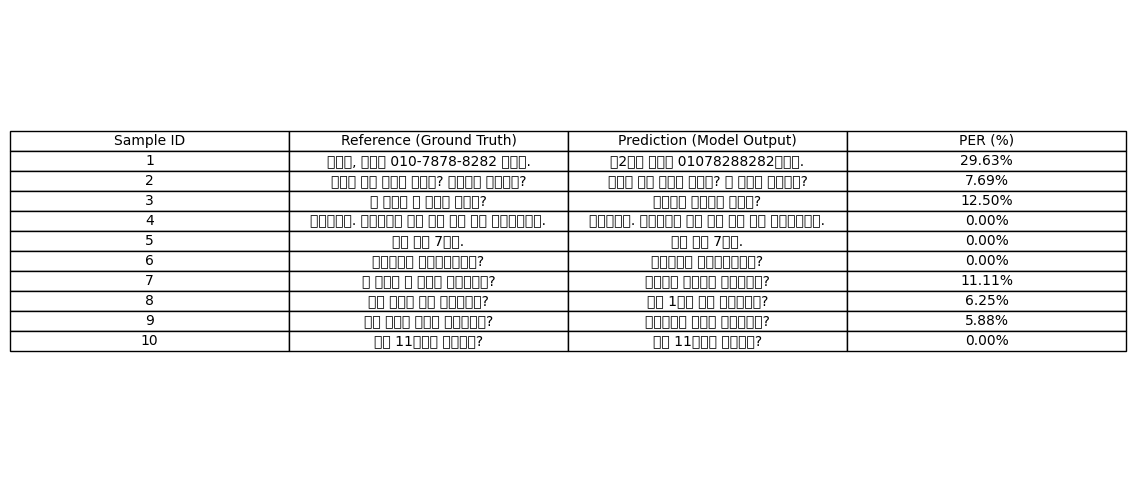

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def save_table_as_image(df, filename):
    fig, ax = plt.subplots(figsize=(12, 6)) # Adjust size as needed
    ax.axis('off')

    # Create the table
    tbl = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

    # Basic styling for a professional look
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.2)

    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"📸 Presentation-ready image saved: {filename}")

image_path = os.path.join(results_dir, "performance_table_slide.png")
save_table_as_image(report_df, image_path)

In [ ]:
from jiwer import cer
from tqdm.auto import tqdm
import torch

def calculate_global_metrics(model, dataset, processor):
    model.eval()
    references = []
    predictions = []

    print(f"🧪 Processing all {len(dataset)} validation samples for the final report...")

    for i in tqdm(range(len(dataset)), desc="Calculating PER"):
        # 1. Prepare Data
        sample = dataset[i]
        input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to("cuda")

        # 2. Reference (Ground Truth Jamo)
        # We decode the labels back to raw Jamo strings for phonetic comparison
        ref_jamo = processor.decode(sample["labels"], group_tokens=False).replace("[PAD]", "").replace("|", " ").strip()
        references.append(ref_jamo)

        # 3. Model Prediction (Predicted Jamo)
        with torch.no_grad():
            logits = model(input_values).logits
        pred_ids = torch.argmax(logits, dim=-1)
        pred_jamo = processor.batch_decode(pred_ids)[0]
        predictions.append(pred_jamo)

    # 4. Compute Global Mean PER
    # In this Jamo-based Wav2Vec 2.0 context, CER on Jamo strings is the PER
    mean_per = cer(references, predictions)
    return mean_per

# Execute the calculation
final_global_per = calculate_global_metrics(model, val_dataset, processor)

print(f"\n✨ --- GRADUATION PROJECT SUMMARY --- ✨")
print(f"📊 Global Mean Phoneme Error Rate (PER): {final_global_per * 100:.2f}%")
print(f"✅ Theoretical Accuracy: {(1 - final_global_per) * 100:.2f}%")

🧪 Processing all 1000 validation samples for the final report...


Calculating PER:   0%|          | 0/1000 [00:00<?, ?it/s]


✨ --- GRADUATION PROJECT SUMMARY --- ✨
📊 Global Mean Phoneme Error Rate (PER): 7.85%
✅ Theoretical Accuracy: 92.15%


In [ ]:
import os

checkpoint_dir = "/content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo"

# List everything saved there
for f in os.listdir(checkpoint_dir):
    print(f)

checkpoint-3100
checkpoint-3130
asr_jamo_performance_report.csv
performance_table_slide.png
asr_jamo_performance_report.xlsx


In [ ]:
import json

# Load trainer state from the latest checkpoint
checkpoint_path = "/content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo/checkpoint-3130/trainer_state.json"

with open(checkpoint_path, "r") as f:
    trainer_state = json.load(f)

log_history = trainer_state["log_history"]

print(f"✅ Loaded {len(log_history)} log entries")
print(log_history[:3])  # preview

✅ Loaded 313 log entries
[{'epoch': 0.032, 'grad_norm': nan, 'learning_rate': 9e-06, 'loss': 132.866015625, 'step': 10}, {'epoch': 0.064, 'grad_norm': 206.35699462890625, 'learning_rate': 1.9e-05, 'loss': 110.02547607421874, 'step': 20}, {'epoch': 0.096, 'grad_norm': 223.00836181640625, 'learning_rate': 2.9e-05, 'loss': 64.8106201171875, 'step': 30}]


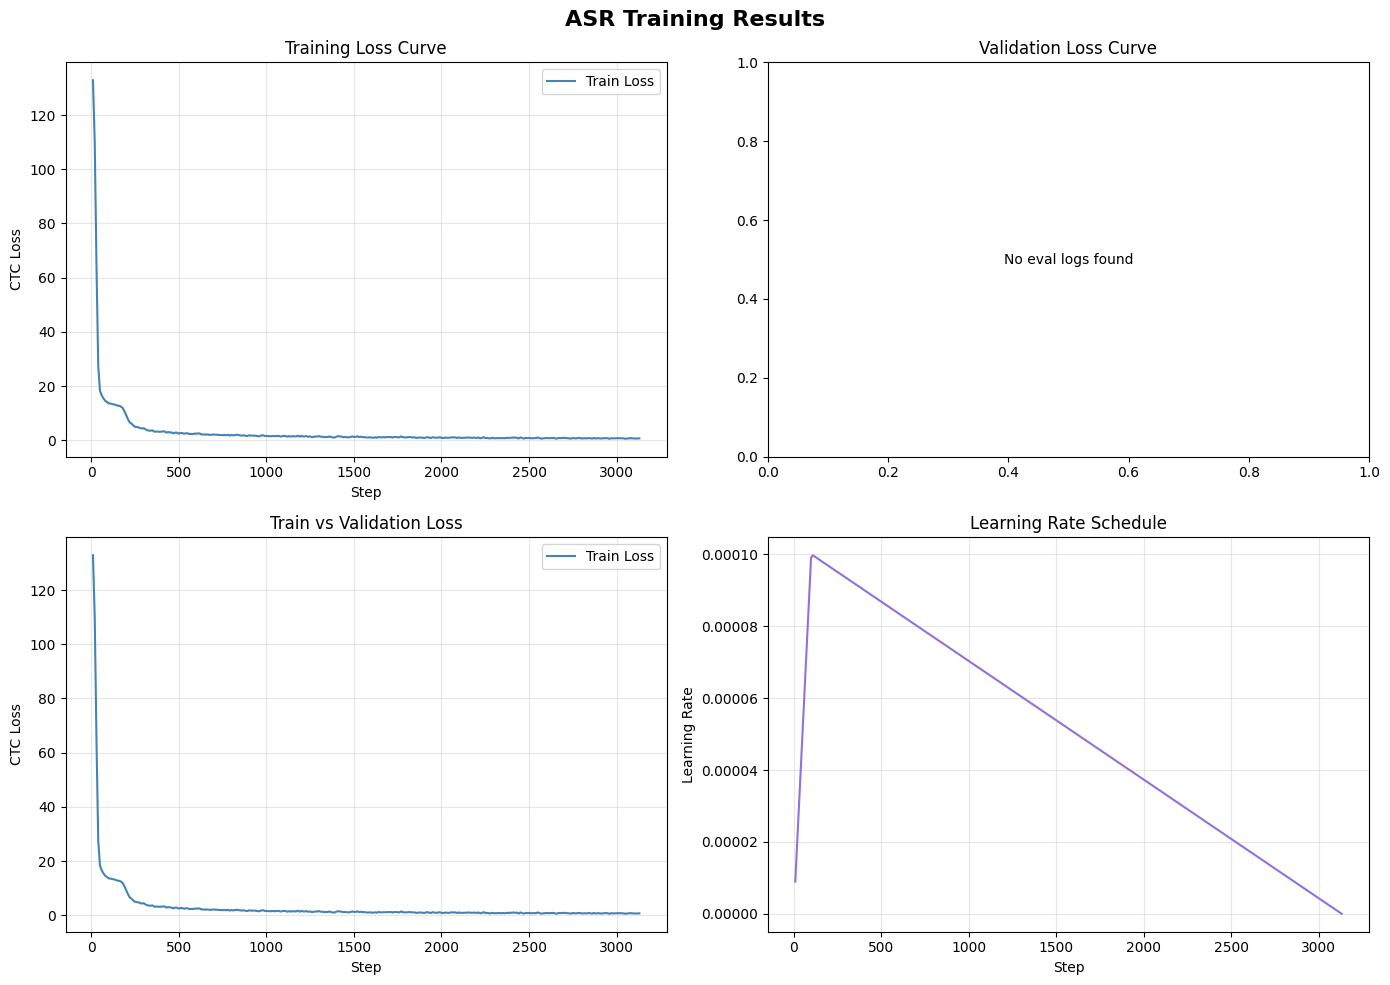

✅ Plots saved to: /content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo/asr_training_plots.png


In [ ]:
import matplotlib.pyplot as plt

# Separate train and eval logs
train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history if "eval_loss" in l]

train_steps  = [l["step"] for l in train_logs]
train_losses = [l["loss"] for l in train_logs]
train_epochs = [l["epoch"] for l in train_logs]
grad_norms   = [l["grad_norm"] for l in train_logs if l["grad_norm"] == l["grad_norm"]]  # filter nan

eval_steps  = [l["step"] for l in eval_logs]
eval_losses = [l["eval_loss"] for l in eval_logs]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ASR Training Results", fontsize=16, fontweight="bold")

# 1. Training loss curve
ax1 = axes[0, 0]
ax1.plot(train_steps, train_losses, color="steelblue", linewidth=1.5, label="Train Loss")
ax1.set_title("Training Loss Curve")
ax1.set_xlabel("Step")
ax1.set_ylabel("CTC Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Eval loss curve
ax2 = axes[0, 1]
if eval_logs:
    ax2.plot(eval_steps, eval_losses, color="tomato", linewidth=1.5, marker="o", label="Eval Loss")
    ax2.set_title("Validation Loss Curve")
    ax2.set_xlabel("Step")
    ax2.set_ylabel("CTC Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, "No eval logs found", ha="center", va="center")
    ax2.set_title("Validation Loss Curve")

# 3. Train vs Eval overlay
ax3 = axes[1, 0]
ax3.plot(train_steps, train_losses, color="steelblue", linewidth=1.5, label="Train Loss")
if eval_logs:
    ax3.plot(eval_steps, eval_losses, color="tomato", linewidth=1.5, marker="o", label="Eval Loss")
ax3.set_title("Train vs Validation Loss")
ax3.set_xlabel("Step")
ax3.set_ylabel("CTC Loss")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Learning rate schedule
ax4 = axes[1, 1]
lr_values = [l["learning_rate"] for l in train_logs]
ax4.plot(train_steps, lr_values, color="mediumpurple", linewidth=1.5)
ax4.set_title("Learning Rate Schedule")
ax4.set_xlabel("Step")
ax4.set_ylabel("Learning Rate")
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Save to Drive
plot_path = "/content/drive/MyDrive/manual_datasets/clovacall_data/asr_results_jamo/asr_training_plots.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Plots saved to: {plot_path}")